In [19]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_blobs

In [3]:
# 500 normal data points: tight cluster around the mean
normal_data = np.random.normal(loc=50, scale=10, size=500)

# print and see the values

# 25 outliers – extreme high values (like $1M transactions)
outliers = np.random.uniform(low=120, high=200, size=25)

# print and see the values

# Combine into one dataset, shuffled
data = np.concatenate([normal_data, outliers])

# print and see the values
np.random.shuffle(data)

In [4]:
df = pd.DataFrame({'value': data})

print(f"Dataset shape: {df.shape}")
print(f"Mean: {df['value'].mean():.2f}")
print(f"Median: {df['value'].median():.2f}  ← outliers pull the mean but barely the median")
print(f"Std: {df['value'].std():.2f}")

Dataset shape: (525, 1)
Mean: 55.13
Median: 50.51  ← outliers pull the mean but barely the median
Std: 26.10


In [10]:
df['z_score'] = stats.zscore(df['value'])
df['is_outlier_z'] = np.abs(df['z_score']) > 3

n_z = df['is_outlier_z'].sum()
print(f"Z-Score flagged {n_z} outliers (threshold: |z| > 3)")
print(f"True outliers in dataset: 25")
print(f"Detection rate: {n_z / 25:.2%}")

Z-Score flagged 21 outliers (threshold: |z| > 3)
True outliers in dataset: 25
Detection rate: 84.00%


In [11]:
df.head()


,value,z_score,is_outlier_z
0,70.948068,0.606392,False
1,42.752712,-0.474770,False
2,45.775606,-0.358856,False
3,59.174170,0.154917,False
4,72.226729,0.655423,False


In [16]:
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['is_outlier_iqr'] = (
    (df['value'] < lower_bound) |
    (df['value'] > upper_bound)
)

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Outlier fences: lower={lower_bound:.2f}, upper={upper_bound:.2f}")
print(f"IQR flagged {df['is_outlier_iqr'].sum()} outliers")

Q1: 42.79, Q3: 57.59, IQR: 14.79
Outlier fences: lower=20.60, upper=79.78
IQR flagged 26 outliers


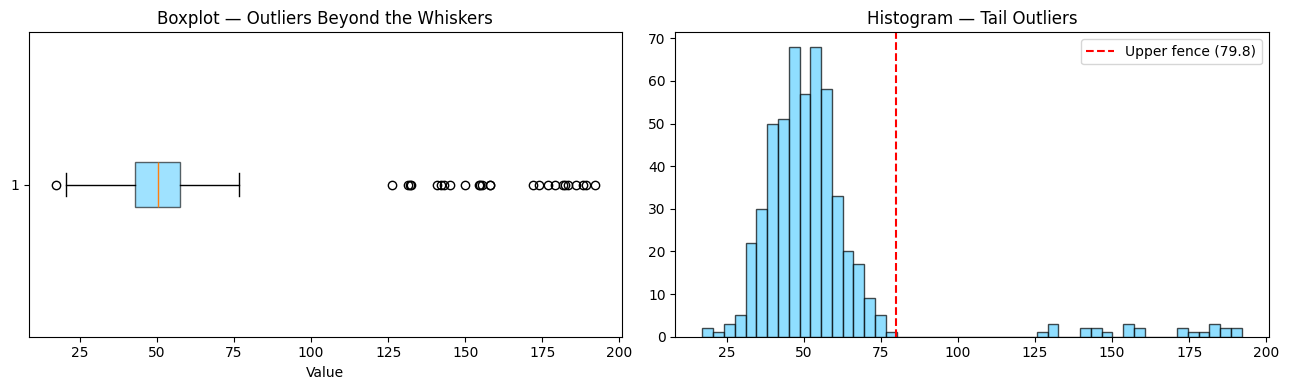

In [17]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Boxplot
axes[0].boxplot(
    df['value'],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#60d0ff', alpha=0.6)
)
axes[0].set_title('Boxplot — Outliers Beyond the Whiskers')
axes[0].set_xlabel('Value')

# Histogram
axes[1].hist(
    df['value'],
    bins=50,
    color='#60d0ff',
    edgecolor='black',
    alpha=0.7
)
axes[1].axvline(
    upper_bound,
    color='red',
    linestyle='--',
    label=f'Upper fence ({upper_bound:.1f})'
)
axes[1].set_title('Histogram — Tail Outliers')
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
# 2D data — 2 dense blobs + scattered outliers
X_normal, _ = make_blobs(n_samples=200, centers=2, cluster_std=0.6, random_state=42)
X_outliers = np.random.uniform(low=-5, high=5, size=(15, 2))
X = np.vstack([X_normal, X_outliers])

In [21]:
# LOF: contamination = expected fraction of outliers (~7% here)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.07)
y_lof = lof.fit_predict(X)   # +1 = inlier, -1 = outlier

LOF flagged 15 outliers


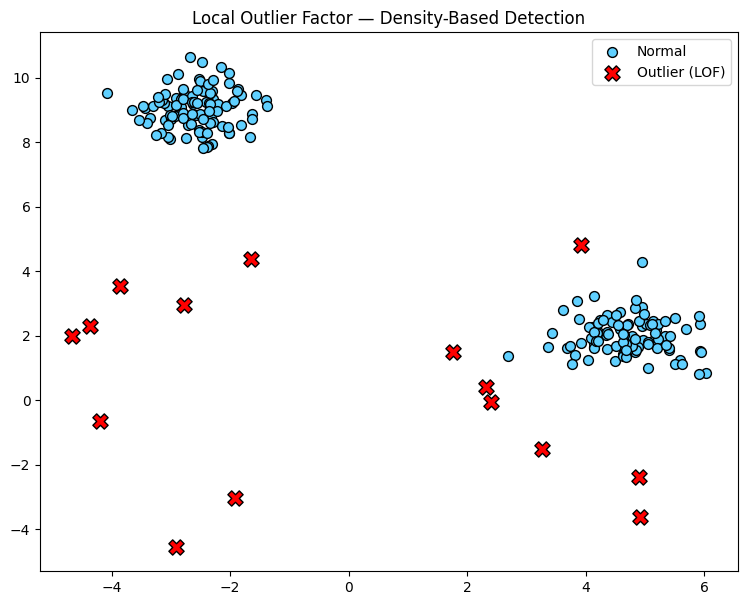

In [22]:
print(f"LOF flagged {(y_lof == -1).sum()} outliers")

plt.figure(figsize=(9, 7))
plt.scatter(X[y_lof == 1][:, 0], X[y_lof == 1][:, 1],
            c='#60d0ff', edgecolors='k', label='Normal', s=50)
plt.scatter(X[y_lof == -1][:, 0], X[y_lof == -1][:, 1],
            c='red', edgecolors='k', marker='X', s=120, label='Outlier (LOF)')
plt.title('Local Outlier Factor — Density-Based Detection')
plt.legend()
plt.show()